# 6.16 - CertCF 2D Gaussian Mixture Coverage Diagnostics

This notebook creates a deliberately non-trivial **2D Gaussian mixture** binary dataset so we can inspect CertCF coverage visually.

Goals:
- build intuition about **coverage** rather than benchmark tables
- visualize how the atlas changes with different `eps_alpha` values
- see where counterfactuals are easy vs hard to obtain
- create a clean sandbox before changing the main tabular pipeline


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from matplotlib.colors import ListedColormap
from torch.utils.data import TensorDataset
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from certcf import CertCFAtlas, NearestOppositeClassClearanceStrategy
from certcf.visualization.plotting import plot_polytopes
from models.classifiers import SimpleClassifier

sns.set_theme(style='whitegrid', context='talk')
np.set_printoptions(precision=4, suppress=True)

torch.set_grad_enabled(True)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print({'device': str(DEVICE), 'seed': SEED})


{'device': 'cuda', 'seed': 42}


## Dataset design

We use a **mixture of anisotropic Gaussians** for each class.

The classes are intentionally multi-modal and interleaved so that:
- a simple linear separator is insufficient
- some target regions are disconnected
- CertCF coverage can be inspected as a union of many local regions


In [2]:
DATASET_CFG = {
    'n_train_per_component': 180,
    'n_test_per_component': 60,
    'class_0': [
        {'mean': (-2.8,  1.8), 'cov': ((0.55,  0.25), (0.25, 0.35))},
        {'mean': ( 0.0, -1.6), 'cov': ((0.45, -0.18), (-0.18, 0.40))},
        {'mean': ( 2.8,  1.6), 'cov': ((0.60,  0.22), (0.22, 0.35))},
    ],
    'class_1': [
        {'mean': (-1.4, -0.2), 'cov': ((0.50, -0.20), (-0.20, 0.45))},
        {'mean': ( 1.5,  0.1), 'cov': ((0.50,  0.18), (0.18, 0.45))},
    ],
}


def _sample_components(components, n_per_component, label, rng):
    xs = []
    ys = []
    for comp in components:
        x = rng.multivariate_normal(mean=np.asarray(comp['mean']), cov=np.asarray(comp['cov']), size=n_per_component)
        y = np.full(n_per_component, label, dtype=np.int64)
        xs.append(x.astype(np.float32))
        ys.append(y)
    return np.concatenate(xs, axis=0), np.concatenate(ys, axis=0)


def make_gaussian_mixture_dataset(cfg, seed=SEED):
    rng = np.random.default_rng(seed)
    x0_tr, y0_tr = _sample_components(cfg['class_0'], cfg['n_train_per_component'], 0, rng)
    x1_tr, y1_tr = _sample_components(cfg['class_1'], cfg['n_train_per_component'], 1, rng)
    x0_te, y0_te = _sample_components(cfg['class_0'], cfg['n_test_per_component'], 0, rng)
    x1_te, y1_te = _sample_components(cfg['class_1'], cfg['n_test_per_component'], 1, rng)

    x_train = np.concatenate([x0_tr, x1_tr], axis=0)
    y_train = np.concatenate([y0_tr, y1_tr], axis=0)
    x_test = np.concatenate([x0_te, x1_te], axis=0)
    y_test = np.concatenate([y0_te, y1_te], axis=0)

    train_perm = rng.permutation(len(x_train))
    test_perm = rng.permutation(len(x_test))
    return x_train[train_perm], y_train[train_perm], x_test[test_perm], y_test[test_perm]


X_TRAIN, Y_TRAIN_TRUE, X_TEST, Y_TEST_TRUE = make_gaussian_mixture_dataset(DATASET_CFG)
print({
    'train_shape': X_TRAIN.shape,
    'test_shape': X_TEST.shape,
    'train_class_counts': {int(c): int((Y_TRAIN_TRUE == c).sum()) for c in np.unique(Y_TRAIN_TRUE)},
    'test_class_counts': {int(c): int((Y_TEST_TRUE == c).sum()) for c in np.unique(Y_TEST_TRUE)},
})


{'train_shape': (900, 2), 'test_shape': (300, 2), 'train_class_counts': {0: 540, 1: 360}, 'test_class_counts': {0: 180, 1: 120}}


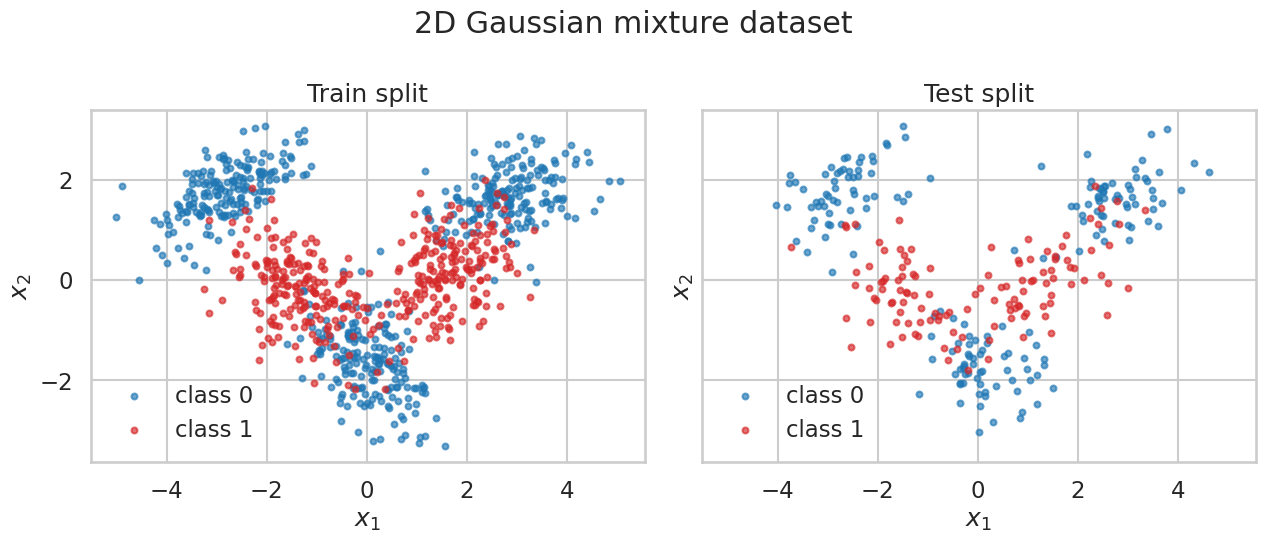

In [3]:
def plot_dataset(x_train, y_train, x_test, y_test, title='2D Gaussian mixture dataset'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    palette = {0: '#1f77b4', 1: '#d62728'}
    for ax, x, y, split in [
        (axes[0], x_train, y_train, 'Train'),
        (axes[1], x_test, y_test, 'Test'),
    ]:
        for cls in sorted(np.unique(y)):
            mask = y == cls
            ax.scatter(x[mask, 0], x[mask, 1], s=18, alpha=0.65, c=palette[cls], label=f'class {cls}')
        ax.set_title(f'{split} split')
        ax.set_xlabel('$x_1$')
        ax.set_ylabel('$x_2$')
        ax.legend(frameon=False)
        ax.set_aspect('equal')
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig, axes


plot_dataset(X_TRAIN, Y_TRAIN_TRUE, X_TEST, Y_TEST_TRUE)
plt.show()


## Train a small 2D classifier

We train a small torch classifier locally in the notebook.

This is enough for diagnostics; we do not need Lightning here.


In [7]:
TRAIN_CFG = {
    'hidden_dims': (64, 32),
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'epochs': 400,
    'batch_size': 128,
}


def train_classifier(x_train, y_train, x_test, y_test, cfg, device=DEVICE):
    model = SimpleClassifier(input_dim=2, hidden_dims=cfg['hidden_dims'], num_classes=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss()

    x_train_t = torch.from_numpy(x_train).float().to(device)
    y_train_t = torch.from_numpy(y_train).long().to(device)
    x_test_t = torch.from_numpy(x_test).float().to(device)
    y_test_t = torch.from_numpy(y_test).long().to(device)

    history = []
    for epoch in range(cfg['epochs']):
        model.train()
        perm = torch.randperm(len(x_train_t), device=device)
        for start in range(0, len(x_train_t), cfg['batch_size']):
            idx = perm[start:start + cfg['batch_size']]
            logits = model(x_train_t[idx])
            loss = criterion(logits, y_train_t[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch in {0, 49, 99, 199, cfg['epochs'] - 1}:
            model.eval()
            with torch.no_grad():
                train_acc = (model(x_train_t).argmax(dim=1) == y_train_t).float().mean().item()
                test_acc = (model(x_test_t).argmax(dim=1) == y_test_t).float().mean().item()
            history.append({'epoch': epoch + 1, 'train_acc': train_acc, 'test_acc': test_acc})
    return model.eval(), history


MODEL, TRAIN_HISTORY = train_classifier(X_TRAIN, Y_TRAIN_TRUE, X_TEST, Y_TEST_TRUE, TRAIN_CFG)
for epoch_info in TRAIN_HISTORY:
    print(f"Epoch {epoch_info['epoch']}: Train Acc = {epoch_info['train_acc']:.4f}, Test Acc = {epoch_info['test_acc']:.4f}")


Epoch 1: Train Acc = 0.6000, Test Acc = 0.6000
Epoch 50: Train Acc = 0.8933, Test Acc = 0.8900
Epoch 100: Train Acc = 0.8978, Test Acc = 0.8800
Epoch 200: Train Acc = 0.9000, Test Acc = 0.8833
Epoch 400: Train Acc = 0.9000, Test Acc = 0.8833


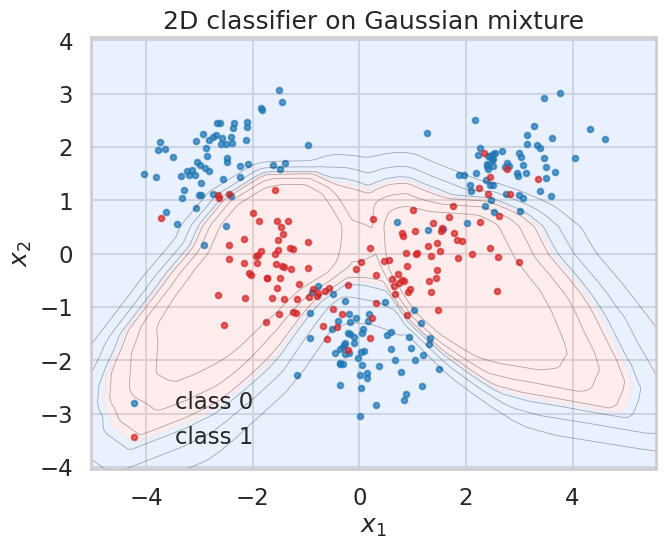

In [8]:
@torch.no_grad()
def predict_np(model, x, device=DEVICE):
    x_t = torch.from_numpy(np.asarray(x, dtype=np.float32)).to(device)
    logits = model(x_t)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)
    return preds, probs


def plot_decision_boundary(model, x, y, title='Classifier decision boundary', grid_step=0.05):
    x_min, x_max = x[:, 0].min() - 1.0, x[:, 0].max() + 1.0
    y_min, y_max = x[:, 1].min() - 1.0, x[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step), np.arange(y_min, y_max, grid_step))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds, probs = predict_np(model, grid)
    zz = preds.reshape(xx.shape)
    conf = probs.max(axis=1).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 7))
    cmap = ListedColormap(['#cfe2ff', '#ffd6d6'])
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], cmap=cmap, alpha=0.45)
    ax.contour(xx, yy, conf, levels=[0.55, 0.70, 0.85], colors='k', linewidths=0.6, alpha=0.35)
    for cls, color in [(0, '#1f77b4'), (1, '#d62728')]:
        mask = y == cls
        ax.scatter(x[mask, 0], x[mask, 1], s=16, alpha=0.7, c=color, label=f'class {cls}')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(frameon=False)
    ax.set_aspect('equal')
    fig.tight_layout()
    return fig, ax


plot_decision_boundary(MODEL, X_TEST, Y_TEST_TRUE, title='2D classifier on Gaussian mixture')
plt.show()


## Build CertCF atlases at different `eps_alpha`

Important choice:
- we use **predicted** training labels as support labels, matching the current benchmark semantics.

We compare multiple `eps_alpha` values to inspect the trade-off between region size and visual coverage.


In [9]:
ALPHAS = [0.25, 0.45, 0.99]
ATLAS_CFG = {
    'norm': 1,
    'distance_norm': 1,
    'lirpa_method': 'backward',
    'batch_size': 256,
}

Y_TRAIN_PRED, _ = predict_np(MODEL, X_TRAIN)
print({'predicted_train_class_counts': {int(c): int((Y_TRAIN_PRED == c).sum()) for c in np.unique(Y_TRAIN_PRED)}})

atlas_bundle = {}
for alpha in ALPHAS:
    ds = TensorDataset(
        torch.from_numpy(X_TRAIN).float(),
        torch.from_numpy(Y_TRAIN_PRED).long(),
    )
    atlas = CertCFAtlas(
        MODEL,
        ds,
        DEVICE,
        cnn=False,
        norm=ATLAS_CFG['norm'],
        distance_norm=ATLAS_CFG['distance_norm'],
        lirpa_method=ATLAS_CFG['lirpa_method'],
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=alpha),
        batch_size=ATLAS_CFG['batch_size'],
        default_query_method='nearest_anchor',
        solver_maxiter=500,
    )
    atlas.build(build_unions=True, verbose=True)
    atlas_bundle[alpha] = atlas

print('Built atlases for alphas:', list(atlas_bundle))


{'predicted_train_class_counts': {0: 560, 1: 340}}
Building certified atlas (eps in [0.0146, 0.5315] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:12<00:00,  6.13s/it]


  Building BVH spatial indices...
    Class 0: 560 polytopes, tree depth 11
    Class 1: 340 polytopes, tree depth 10
  Building polygon unions...
Done! Total: 900 polytopes across 2 classes
Building certified atlas (eps in [0.02629, 0.9567] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:12<00:00,  6.11s/it]


  Building BVH spatial indices...
    Class 0: 560 polytopes, tree depth 11
    Class 1: 340 polytopes, tree depth 10
  Building polygon unions...
Done! Total: 900 polytopes across 2 classes
Building certified atlas (eps in [0.05783, 2.105] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:12<00:00,  6.14s/it]

  Building BVH spatial indices...
    Class 0: 560 polytopes, tree depth 11
    Class 1: 340 polytopes, tree depth 10
  Building polygon unions...
Done! Total: 900 polytopes across 2 classes
Built atlases for alphas: [0.25, 0.45, 0.99]


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/src/certcf/visualization/plotting.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_classes)


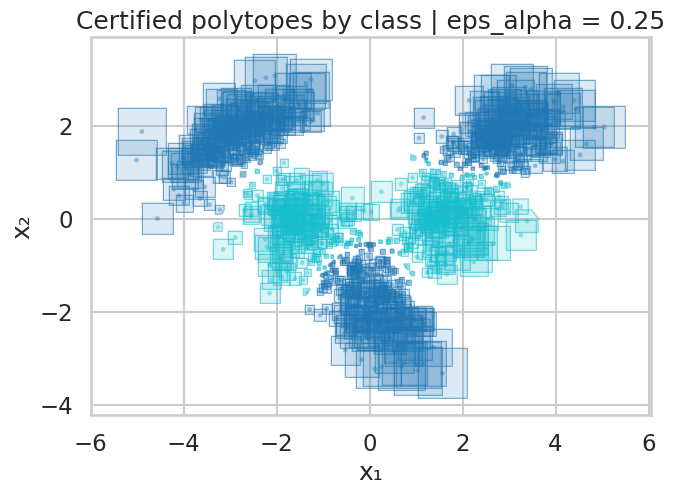

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/src/certcf/visualization/plotting.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_classes)


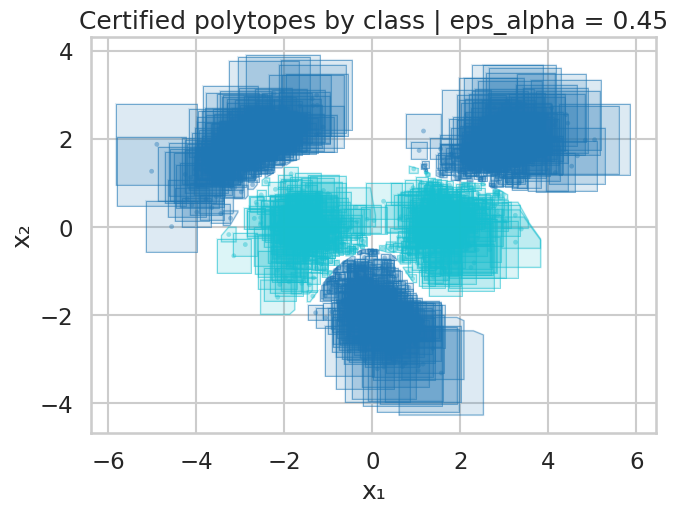

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/src/certcf/visualization/plotting.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_classes)


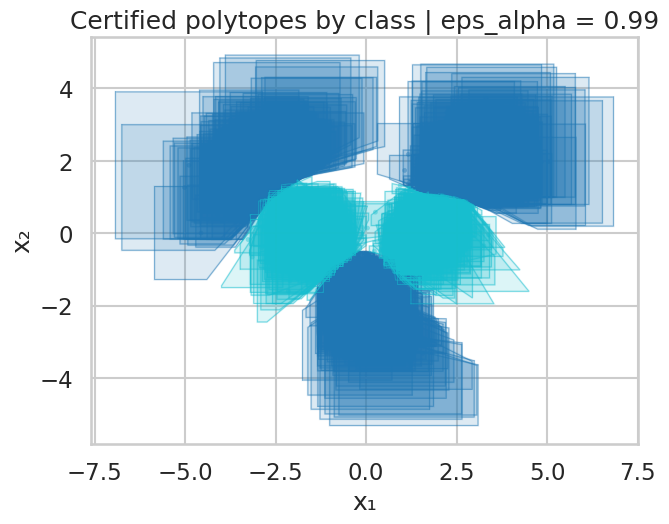

In [10]:
for alpha, atlas in atlas_bundle.items():
    fig, ax = plot_polytopes(
        atlas.bounds,
        eps=0.1,
        n_classes=atlas.n_classes,
        figsize=(7, 7),
    )
    ax.set_title(f'Certified polytopes by class | eps_alpha = {alpha}')
    plt.show()


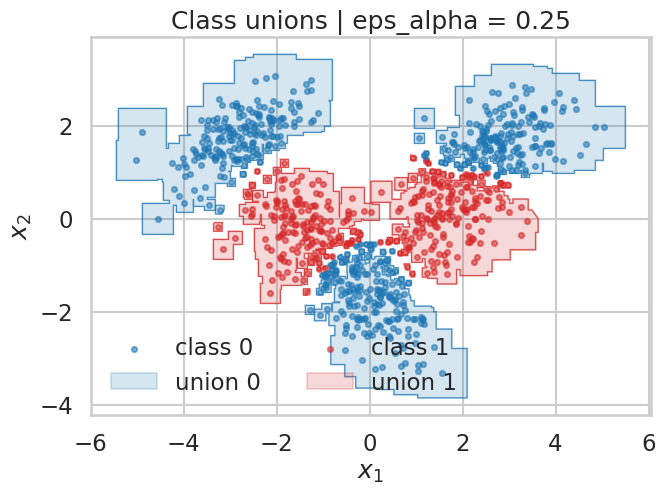

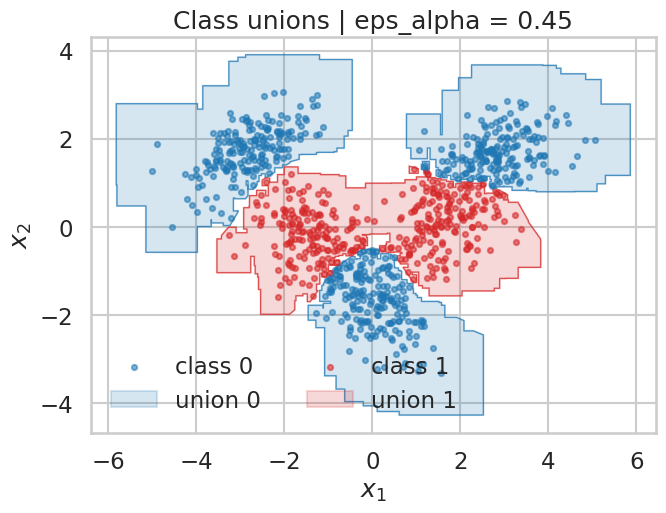

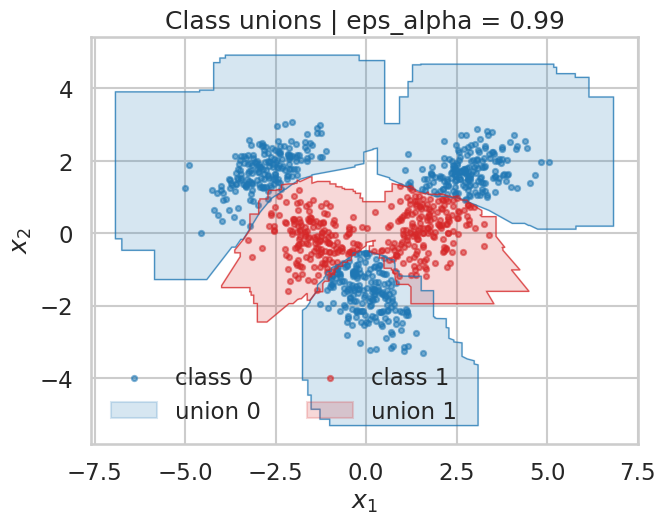

In [11]:
def plot_union_overlay(atlas, x, y, title):
    fig, ax = plt.subplots(figsize=(7, 7))
    colors = {0: '#1f77b4', 1: '#d62728'}
    for cls in sorted(np.unique(y)):
        mask = y == cls
        ax.scatter(x[mask, 0], x[mask, 1], s=14, alpha=0.55, c=colors[cls], label=f'class {cls}')
        geom = atlas._class_unions.get(int(cls)) if atlas._class_unions is not None else None
        if geom is not None and not geom.is_empty:
            geoms = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
            for i, g in enumerate(geoms):
                xs, ys = g.exterior.xy
                ax.fill(xs, ys, color=colors[cls], alpha=0.18, label=f'union {cls}' if i == 0 else None)
                ax.plot(xs, ys, color=colors[cls], lw=0.9, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(frameon=False, ncol=2)
    ax.set_aspect('equal')
    fig.tight_layout()
    return fig, ax


for alpha, atlas in atlas_bundle.items():
    plot_union_overlay(atlas, X_TRAIN, Y_TRAIN_PRED, title=f'Class unions | eps_alpha = {alpha}')
    plt.show()


## Query examples

We pick a few test points, ask for a counterfactual toward the opposite class, and overlay:
- original query point
- returned counterfactual
- connection segment

This helps us distinguish:
- good coverage with short moves
- good coverage with long moves
- missing or thin target regions


In [12]:
QUERY_CFG = {
    'method': 'nearest_anchor',
    'query_k_candidates': 3,
    'delta': 0.0,
}


def choose_queries(x, y, max_per_class=3):
    chosen = []
    for cls in sorted(np.unique(y)):
        idx = np.where(y == cls)[0][:max_per_class]
        chosen.extend(idx.tolist())
    return chosen


QUERY_IDXS = choose_queries(X_TEST, Y_TEST_TRUE, max_per_class=3)
print('query_idxs', QUERY_IDXS)


query_idxs [1, 2, 5, 0, 3, 4]


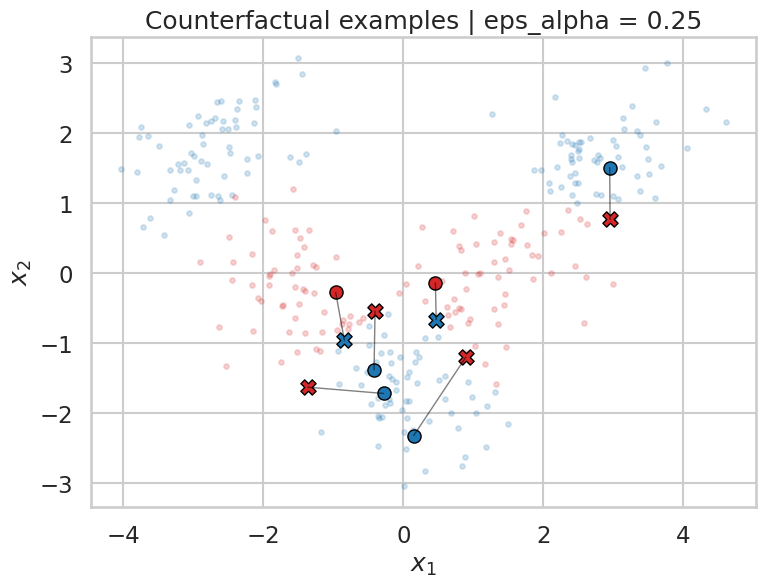

[{'query_idx': 1,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 1.1714403962858673,
  'n_qp_solved': 3},
 {'query_idx': 2,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 1.8655507795425146,
  'n_qp_solved': 3},
 {'query_idx': 5,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 0.7443535625280512,
  'n_qp_solved': 3},
 {'query_idx': 0,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.8086847889147573,
  'n_qp_solved': 3},
 {'query_idx': 3,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.5375364868999132,
  'n_qp_solved': 3},
 {'query_idx': 4,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 0.8558740512741061,
  'n_qp_solved': 3}]

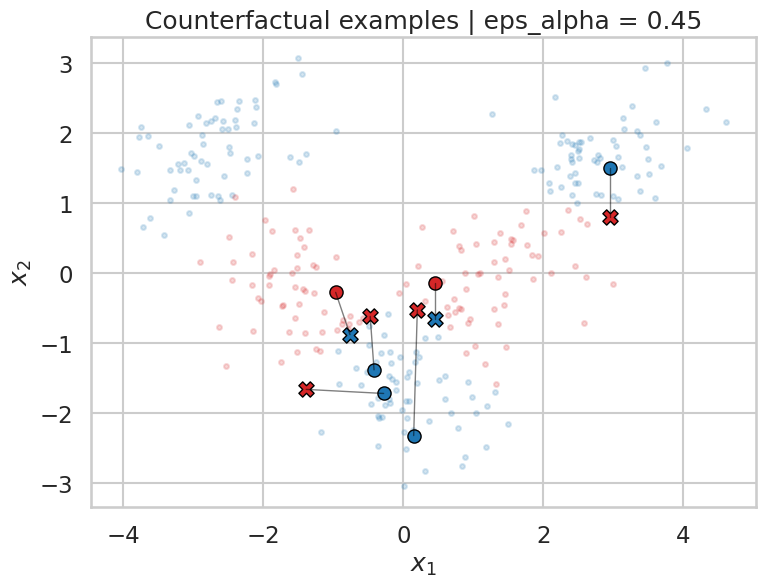

[{'query_idx': 1,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 1.1642410476582434,
  'n_qp_solved': 3},
 {'query_idx': 2,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 1.8472007692440404,
  'n_qp_solved': 3},
 {'query_idx': 5,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 0.705245731228209,
  'n_qp_solved': 3},
 {'query_idx': 0,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.8083417350619657,
  'n_qp_solved': 3},
 {'query_idx': 3,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.514448611380351,
  'n_qp_solved': 3},
 {'query_idx': 4,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 0.8183445455428857,
  'n_qp_solved': 3}]

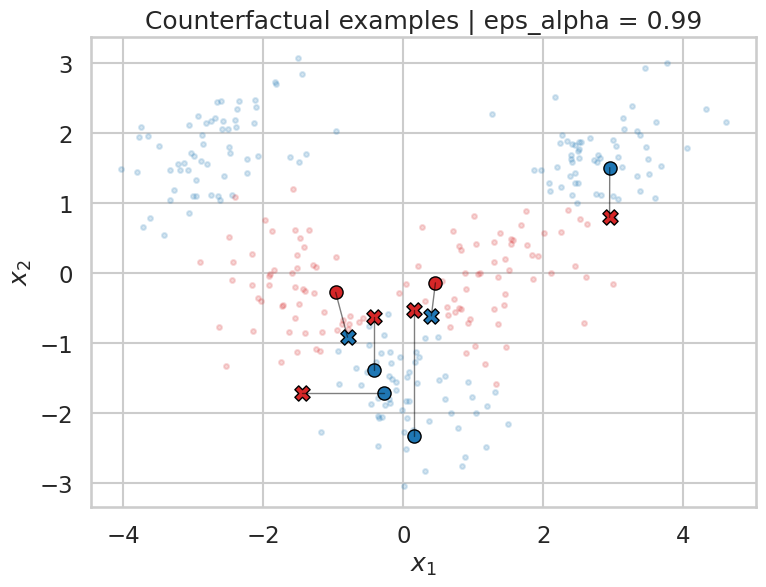

[{'query_idx': 1,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 1.1701096394918913,
  'n_qp_solved': 3},
 {'query_idx': 2,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 1.7998930632642989,
  'n_qp_solved': 3},
 {'query_idx': 5,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 0.7129422783979237,
  'n_qp_solved': 3},
 {'query_idx': 0,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.8101722584064948,
  'n_qp_solved': 3},
 {'query_idx': 3,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.5290396196131644,
  'n_qp_solved': 3},
 {'query_idx': 4,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 0.7568338626702755,
  'n_qp_solved': 3}]

In [13]:
def plot_counterfactual_examples(atlas, x_test, y_test, query_indices, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = {0: '#1f77b4', 1: '#d62728'}

    y_pred_test, _ = predict_np(MODEL, x_test)
    for cls in sorted(np.unique(y_pred_test)):
        mask = y_pred_test == cls
        ax.scatter(x_test[mask, 0], x_test[mask, 1], s=12, alpha=0.18, c=colors[cls])

    rows = []
    for idx in query_indices:
        xq = x_test[idx]
        yq = int(y_pred_test[idx])
        target = 1 - yq
        result = atlas.find_counterfactual(
            xq,
            target_class=target,
            method=QUERY_CFG['method'],
            delta=QUERY_CFG['delta'],
            query_k_candidates=QUERY_CFG['query_k_candidates'],
        )
        rows.append({
            'query_idx': idx,
            'y_pred': yq,
            'target': target,
            'success': bool(result.success),
            'distance': float(result.distance),
            'n_qp_solved': int(result.n_qp_solved),
        })
        ax.scatter([xq[0]], [xq[1]], c=colors[yq], s=90, marker='o', edgecolors='black', linewidths=1.0)
        if result.x_cf is not None and np.all(np.isfinite(result.x_cf)):
            xcf = np.asarray(result.x_cf)
            ax.scatter([xcf[0]], [xcf[1]], c=colors[target], s=120, marker='X', edgecolors='black', linewidths=1.0)
            ax.plot([xq[0], xcf[0]], [xq[1], xcf[1]], color='black', alpha=0.5, lw=1.0)
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')
    fig.tight_layout()
    return fig, ax, rows


for alpha, atlas in atlas_bundle.items():
    fig, ax, rows = plot_counterfactual_examples(
        atlas,
        X_TEST,
        Y_TEST_TRUE,
        QUERY_IDXS,
        title=f'Counterfactual examples | eps_alpha = {alpha}',
    )
    plt.show()
    display(rows)


## Questions to ask after running

Use this notebook to inspect:
- Does larger `eps_alpha` visibly cover more target-class area?
- Does it create thicker, more useful regions or only larger redundant ones?
- Where do queries fail or require long moves?
- Are disconnected target-class regions left uncovered?
- Would more anchors help more than larger `eps_alpha`?

This notebook is meant to guide the next CertCF coverage experiments, not to serve as a final benchmark notebook.
